# 2D Taylor-Green

## Raw Moments Collision

In [7]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors
from IPython.display import display, Math, Latex
import time
Nx=40
Ny=Nx
# ---------------------------Lattice-Properties--------------------------------------------
w0=4.0/9.0;w1=1.0/9.0;w2=1.0/36.0; # Lattice Weights
w = np.array([w0,w1,w1,w1,w1,w2,w2,w2,w2],dtype="float64") 
cx = np.array([0,1,0,-1, 0,1,-1,-1, 1],dtype="int8")  # Lattice Directions
cy = np.array([0,0,1, 0,-1,1, 1,-1,-1],dtype="int8")  # Lattice Directions
# opp = np.array([0,3,4,1,2,7,8,5,6],dtype="uint8")  # Opposite Lattice Directions
#------------Dimensionless Parameter For Pro----------------
uo = 1.0 # Dimensionless Velocity
ho = 1.0 # Dimensionless Domain Length
Re = 30.0 # Reynolds Number
nuo = uo*ho/Re #Dimensionless Kinematic Viscosity
#------------------------------------------Scaling Term--------------------------------------------
dx = ho / (Nx) # Grid size 
r = 2.0**(3) # Relation term r=dx/dt
dt = dx / r # Time Step
#----------------------------------------LBM-Scale-----------------------------------------------
nu = dt * nuo / (dx * dx)  #Scaling Viscosity
ue = dt * uo / dx  #Scaling Velocity
cs = 1.0 / np.sqrt(3.) #Sound Speed
tau = (nu/ (cs * cs)) + (1.0/ 2.0) #Relaxation time
rhoi = 1.0 #Initial Densty
mstep=100
#--------------Print-Data-------------------------------------------------------------------------
display(Math(r"\tau="+str(tau)+r"\quad\quad \nu="+str(nu)))
display(Math(r"r="+str(r)+r"\quad\quad \overline{u}="+str(ue)))
display(Math(r"dx="+str(dx)+r"\quad\quad dt="+str(dt)))
#---------------------Field-Arrays---------------------------------------------------------------- 
Mass=np.zeros((mstep),dtype="float64") # Allocating Density field
Enr=np.zeros((mstep),dtype="float64") # Allocating Density field
rho=np.zeros((Nx,Ny),dtype="float64") # Allocating Density field
Vx=np.zeros((Nx,Ny),dtype="float64") # Allocating Null Velocity x Field
Vy=np.zeros((Nx,Ny),dtype="float64") # Allocating Null Velocity y Field
# ----------------------------Init Field------------------------------------------------------
xi = np.arange(Nx, dtype="float64") + 0.5
yi = np.arange(Ny, dtype="float64") + 0.5
Xi, Yi = np.meshgrid(xi, yi, indexing="ij")
rho = rhoi - (rhoi * ue**2 / (4.0 * cs**2)) * (np.cos(4.0 * np.pi * Xi / Nx) + np.cos(4.0 * np.pi * Yi / Ny))    # Density
Vx = -ue * (np.cos(2.0 * np.pi * Xi / Nx) * np.sin(2.0 * np.pi * Yi / Ny)) # Velocity X
Vy = ue * (np.cos(2.0 * np.pi * Yi / Ny) * np.sin(2.0 * np.pi * Xi / Nx)) # Velocity Y
#----------------Initializing Distribution Functions----------------
f=np.zeros((9,Nx,Ny),dtype="float64") # Allocating Pre-Collisional Distribution Function
fp=np.zeros((9,Nx,Ny),dtype="float64") # Allocating Pos-Collisional Distribution Function
feq=np.zeros((9,Nx,Ny),dtype="float64") # Allocating Pos-Collisional Distribution Function
for k in range (0,9):
    f[k,:,:]=w[k]*rho*(1. + 3.*(Vx*cx[k]+Vy*cy[k]) + 4.5*(Vx*cx[k]+Vy*cy[k])**2-1.5*(Vx*Vx+Vy*Vy))
#---------------------------------Main-Loop-------------------------------------------------------
En=0.0; 
start=time.time()
for kk in range(0,mstep):
    #------------------------------------Collision-----------------------------------------------------------------------------
    for k in range(0,9):
        feq[k,:,:]=w[k]*rho*(1. + 3.*(Vx*cx[k]+Vy*cy[k]) + 4.5*(Vx*cx[k]+Vy*cy[k])**2-1.5*(Vx*Vx+Vy*Vy))
        fp[k,:,:]=f[k,:,:]-(1.0/tau)*(f[k,:,:]-feq[k,:,:])
    #----------------------------------Streaming---------------------------------------------------------------------------
    for k in range(0,9):
        f[k,:,:]=np.roll(np.roll(fp[k,:,:], cx[k], axis=0), cy[k], axis=1)
    #--------------------------------------Macro-Properties------------------------------------------------------------------
    rho=np.einsum('ixy->xy', f)
    Vx=np.einsum('i,ixy->xy', cx, f)/rho
    Vy=np.einsum('i,ixy->xy', cy, f)/rho
    #-------------------------------------Convergence------------------------------------------------------------------------
    Mass[kk] = np.sum(rho)/(Nx*Ny)
    Umed = np.sum(np.abs(Vx))/(Nx*Ny)
    print('|Umed|=',np.fabs(Umed) )
    Enr[kk]=Umed

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

|Umed|= 0.050342063932128284
|Umed|= 0.049917957859596046
|Umed|= 0.04949411065377911
|Umed|= 0.049072206220411536
|Umed|= 0.04865393285883249
|Umed|= 0.048240850198540956
|Umed|= 0.047834272177555655
|Umed|= 0.04743517598507372
|Umed|= 0.04704414435976784
|Umed|= 0.046661345203976336
|Umed|= 0.04628654852433639
|Umed|= 0.045919176756205535
|Umed|= 0.045558381133806274
|Umed|= 0.04520313442129617
|Umed|= 0.04485232933401725
|Umed|= 0.04450487242081671
|Umed|= 0.044159764863498215
|Umed|= 0.0438161641979098
|Umed|= 0.04347342389219296
|Umed|= 0.043131110557205934
|Umed|= 0.04278900093376272
|Umed|= 0.04244706247061508
|Umed|= 0.04210542220333768
|Umed|= 0.04176432882786687
|Umed|= 0.04142411248232149
|Umed|= 0.04108514599533539
|Umed|= 0.040747810414748696
|Umed|= 0.04041246665314297
|Umed|= 0.040079434188426556
|Umed|= 0.03974897700493752
|Umed|= 0.03942129638054801
|Umed|= 0.03909652971637447
|Umed|= 0.03877475434859073
|Umed|= 0.03845599514933999
|Umed|= 0.038140234688188585
|Umed|= 

Da= 2.2671267902787555 	 Diff= 5.24469356832924e-13 	 Umed= 0.030755661960068757 	 Erro= 0.1328732097212444
Da= 2.267126790279089 	 Diff= 3.33510996597397e-13 	 Umed= 0.030755661960068688 	 Erro= 0.13287320972091088
Da= 2.267126790279118 	 Diff= 2.886579864025407e-14 	 Umed= 0.030755661960068716 	 Erro= 0.132873209720882
Da= 2.2671267902794248 	 Diff= 3.0686564400639327e-13 	 Umed= 0.030755661960068785 	 Erro= 0.13287320972057515
Da= 2.267126790279061 	 Diff= 3.637090628672013e-13 	 Umed= 0.030755661960068716 	 Erro= 0.13287320972093886
Da= 2.267126790278939 	 Diff= 1.2212453270876722e-13 	 Umed= 0.030755661960068667 	 Erro= 0.13287320972106098
Da= 2.267126790278952 	 Diff= 1.2878587085651816e-14 	 Umed= 0.030755661960068757 	 Erro= 0.1328732097210481
Da= 2.2671267902792893 	 Diff= 3.375077994860476e-13 	 Umed= 0.030755661960068636 	 Erro= 0.1328732097207106
Da= 2.2671267902792813 	 Diff= 7.993605777301127e-15 	 Umed= 0.030755661960068705 	 Erro= 0.1328732097207186
Da= 2.26712679027908

Text(0, 0.5, '$Y$')

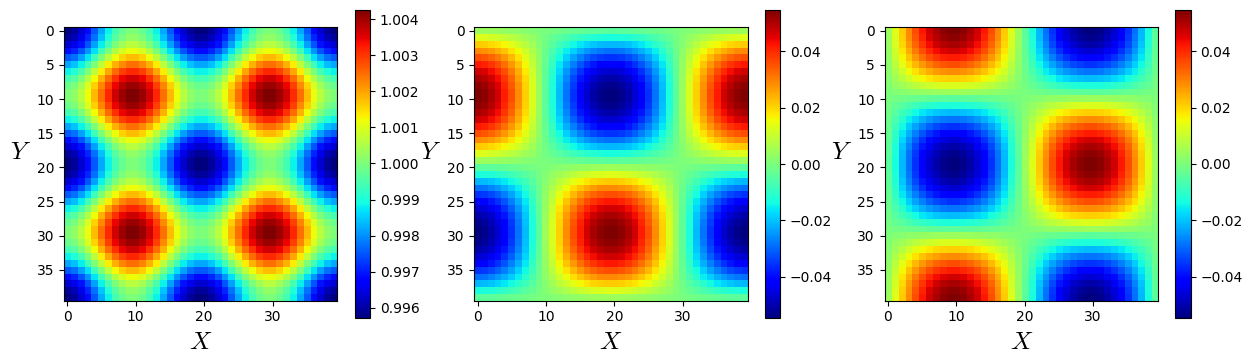

In [8]:
matplotlib.rcParams['mathtext.fontset'] = 'cm'
fig1, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(15,4))
img1=ax1.imshow(np.rot90(rho[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img1, ax=ax1)
ax1.set_xlabel('$X$',fontsize=18)
ax1.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0)
img2=ax2.imshow(np.rot90(Vx[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img2, ax=ax2)
ax2.set_xlabel('$X$',fontsize=18)
ax2.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 
img3=ax3.imshow(np.rot90(Vy[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img3, ax=ax3)
ax3.set_xlabel('$X$',fontsize=18)
ax3.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 

Text(0.5, 0, '$t$')

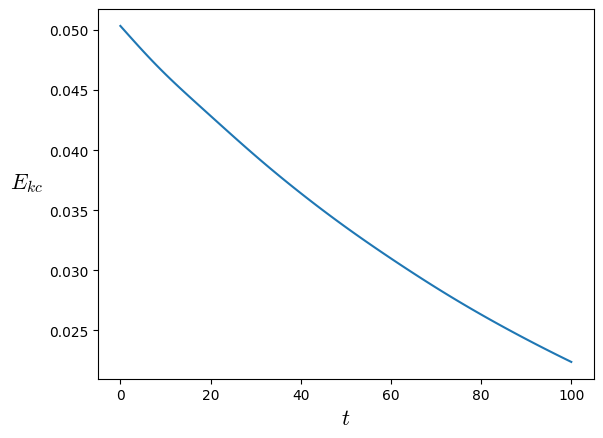

In [9]:
plt.plot(np.linspace(0,len(Enr),len(Enr)),Enr)
plt.ylabel('$E_{kc}$',fontsize=16,rotation=0,horizontalalignment='right')
plt.xlabel('$t$',fontsize=16)

Text(0.5, 0, '$t$')

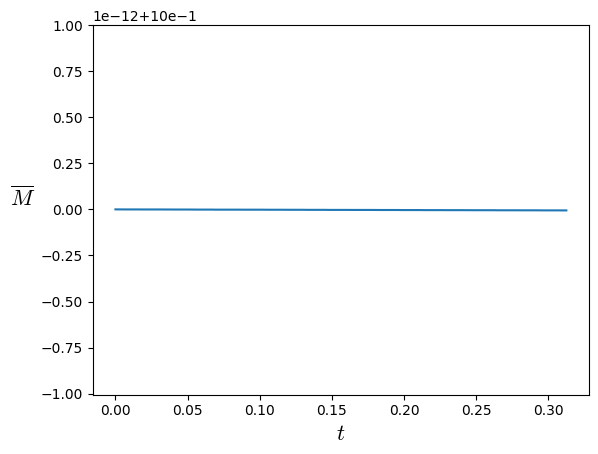

In [10]:
plt.plot(np.linspace(0,len(Mass),len(Mass))/Nx/r,Mass)
plt.ylabel('$\overline{M}$',fontsize=16,rotation=0,horizontalalignment='right')
plt.xlabel('$t$',fontsize=16)

## Central Moments Collision

In [15]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors
from IPython.display import display, Math, Latex
import time
# ===================================Domain=======================================================
Nx = 40
Ny = Nx
# ==================================D2Q9 lattice========================================================
w0 = 4.0 / 9.0; w1 = 1.0 / 9.0; w2 = 1.0 / 36.0
w = np.array([w0, w1, w1, w1, w1, w2, w2, w2, w2], dtype="float64")
cx = np.array([0, 1, 0, -1, 0, 1, -1, -1, 1], dtype="float64")
cy = np.array([0, 0, 1, 0, -1, 1, 1, -1, -1],dtype="float64")
cs = 1.0 / np.sqrt(3.0)
cs2 = cs**2
cs4 = cs**4
# ==========================================================================================
# Raw-moment basis
# m = [m00,m10,m01,m20,m02,m11,m21,m12,m22]
# m_pq = sum_i f_i cx_i^p cy_i^q
# ==========================================================================================
powers = [(0, 0),(1, 0),(0, 1),(2, 0),(0, 2),(1, 1),(2, 1),(1, 2),(2, 2)]
M = np.zeros((9, 9), dtype="float64")
for j, (px, py) in enumerate(powers):
    M[j, :] = cx**px * cy**py
Minv = np.linalg.inv(M)
# ===================================Dimensionless parameters=======================================================
uo = 1.0
ho = 1.0
Re = 30.0
nuo = uo * ho / Re
# ========================================Scaling==================================================
dx = ho / Nx
r = 2.0**3
dt = dx / r
nu = dt * nuo / (dx * dx)
ue = dt * uo / dx
tau = nu / cs2 + 0.5
rhoi = 1.0
mstep = 100
# ================================Relaxation frequencies==========================================================
omega2 = 1.0 / tau
omega3 = 1.0 / tau
omega4 = 1.0 / tau
# ==============================Information============================================================
display(Math(r"\tau=" + str(tau)+ r"\qquad \nu=" + str(nu)))
display(Math(r"r=" + str(r)+ r"\qquad \overline{u}=" + str(ue)))
display(Math(r"dx=" + str(dx)+ r"\qquad dt=" + str(dt)))
display(Math(r"\omega_2="+ str(omega2)+ r"\qquad \omega_3="+ str(omega3)+ r"\qquad \omega_4="+ str(omega4)))
# =====================================Fields=====================================================
Mass = np.zeros(mstep, dtype="float64")
Enr = np.zeros(mstep, dtype="float64")
rho = np.zeros((Nx, Ny), dtype="float64")
Vx = np.zeros((Nx, Ny), dtype="float64")
Vy = np.zeros((Nx, Ny), dtype="float64")
# ================================Initial Taylor-Green field==========================================================
xi = np.arange(Nx, dtype="float64") + 0.5
yi = np.arange(Ny, dtype="float64") + 0.5
Xi, Yi = np.meshgrid(xi,yi,indexing="ij")
rho = (rhoi- (rhoi * ue**2 / (4.0 * cs2))* (np.cos(4.0 * np.pi * Xi / Nx)+ np.cos(4.0 * np.pi * Yi / Ny)))
Vx = (-ue* np.cos(2.0 * np.pi * Xi / Nx)* np.sin(2.0 * np.pi * Yi / Ny))
Vy = (ue* np.cos(2.0 * np.pi * Yi / Ny)* np.sin(2.0 * np.pi * Xi / Nx))
# ========================Distribution functions==================================================
f = np.zeros((9, Nx, Ny), dtype="float64")
fp = np.zeros((9, Nx, Ny), dtype="float64")
# Standard second-order equilibrium only for initialization
for k in range(9):
    cu = Vx * cx[k] + Vy * cy[k]
    f[k, :, :] = (w[k] * rho * (1.0 + cu / cs2 + 0.5 * cu**2 / cs4 - 0.5 * (Vx**2 + Vy**2) / cs2))
# ======================================Main loop====================================================
start = time.time()
for kk in range(mstep):
    # ========Macroscopic quantities BEFORE collision=======================================
    rho = np.sum(f, axis=0)
    Vx = np.einsum("i,ixy->xy", cx, f) / rho
    Vy = np.einsum("i,ixy->xy", cy, f) / rho
    # ======================================================================================
    # Peculiar velocities: cbar_ix = cx_i - ux - cbar_iy = cy_i - uy
    # ======================================================================================
    Cx = cx[:, None, None] - Vx[None, :, :]
    Cy = cy[:, None, None] - Vy[None, :, :]
    # ======================================================================================
    # CENTRAL MOMENTS
    #
    # kappa_pq = sum_i f_i (cx_i - ux)^p (cy_i - uy)^q
    # ======================================================================================
    k00 = np.sum(f, axis=0)
    k10 = np.sum(f * Cx, axis=0)
    k01 = np.sum(f * Cy, axis=0)
    k20 = np.sum(f * Cx**2, axis=0)
    k02 = np.sum(f * Cy**2, axis=0)
    k11 = np.sum(f * Cx * Cy, axis=0)
    k21 = np.sum(f * Cx**2 * Cy, axis=0)
    k12 = np.sum(f * Cx * Cy**2, axis=0)
    k22 = np.sum(f * Cx**2 * Cy**2, axis=0)
    # ======================================================================================
    # CENTRAL-MOMENT EQUILIBRIUM
    # ======================================================================================
    k00_eq = rho
    k10_eq = 0.0; k01_eq = 0.0
    k20_eq = rho * cs2
    k02_eq = rho * cs2
    k11_eq = 0.0; k21_eq = 0.0; k12_eq = 0.0
    k22_eq = rho * cs4
    # ======================================================================================
    # COLLISION IN CENTRAL-MOMENT SPACE
    # kappa* = kappa - omega (kappa - kappa_eq)
    # ======================================================================================
    # Conserved moments
    k00p = k00
    k10p = k10
    k01p = k01
    # ------------------Second-order moments----------------------------
    k20p = k20 - omega2 * (k20 - k20_eq)
    k02p = k02 - omega2 * (k02 - k02_eq)
    k11p = k11 - omega2 * (k11 - k11_eq)
    # ---------------Third-order moments--------------------------------
    k21p = k21 - omega3 * (k21 - k21_eq)
    k12p = k12 - omega3 * (k12 - k12_eq)
    # ---------------Fourth-order moment--------------------------------
    k22p = k22 - omega4 * (k22 - k22_eq)
    # ======================================================================================
    # Convert POST-COLLISION CENTRAL MOMENTS -> RAW MOMENTS
    # Binomial transformation
    # ======================================================================================
    m00 = k00p
    m10 = k10p + Vx * k00p
    m01 = k01p + Vy * k00p
    # --------------------------------Second order------------------------------------------
    m20 = (k20p + 2.0 * Vx * k10p + Vx**2 * k00p)
    m02 = (k02p + 2.0 * Vy * k01p + Vy**2 * k00p)
    m11 = (k11p + Vx * k01p + Vy * k10p + Vx * Vy * k00p)
    # ------------------------------Third order---------------------------------------------
    m21 = (k21p + Vy * k20p + 2.0 * Vx * k11p + 2.0 * Vx * Vy * k10p + Vx**2 * k01p + Vx**2 * Vy * k00p)
    m12 = (k12p + Vx * k02p + 2.0 * Vy * k11p + 2.0 * Vx * Vy * k01p + Vy**2 * k10p + Vx * Vy**2 * k00p)
    # ------------------------Fourth order--------------------------------------------------
    m22 = (k22p + 2.0 * Vy * k21p + 2.0 * Vx * k12p + Vy**2 * k20p + Vx**2 * k02p + 4.0 * Vx * Vy * k11p 
           + 2.0 * Vx * Vy**2 * k10p + 2.0 * Vx**2 * Vy * k01p + Vx**2 * Vy**2 * k00p)
    # ========================Raw moment vector=============================================
    mpost = np.stack([m00,m10,m01,m20,m02,m11,m21,m12,m22], axis=0)
    # ======================================================================================
    # RAW MOMENTS -> DISTRIBUTION FUNCTIONS
    # f* = M^{-1} m*
    # ======================================================================================
    fp = np.einsum("ij,jxy->ixy",Minv,mpost)
    # =========================Streaming====================================================
    for k in range(9):
        f[k, :, :] = np.roll(np.roll(fp[k, :, :], int(cx[k]), axis=0), int(cy[k]), axis=1)
    # ================================Macroscopic quantities================================
    rho = np.sum(f, axis=0)
    Vx = np.einsum("i,ixy->xy",cx,f) / rho
    Vy = np.einsum("i,ixy->xy",cy,f) / rho
    # =========================Diagnostics==================================================
    Mass[kk] = np.mean(rho)
    Umed = np.mean(np.abs(Vx))
    Enr[kk] = Umed
    print(kk,"|Umed| =",np.abs(Umed)," Mass =",Mass[kk])
print("Elapsed time =", time.time() - start)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

0 |Umed| = 0.05033893035022903  Mass = 1.0
1 |Umed| = 0.04991218877930077  Mass = 1.0
2 |Umed| = 0.049486357810477874  Mass = 1.0
3 |Umed| = 0.04906321027511892  Mass = 1.0
4 |Umed| = 0.04864445522549359  Mass = 1.0
5 |Umed| = 0.04823160790013357  Mass = 1.0
6 |Umed| = 0.04782588162017008  Mass = 1.0
7 |Umed| = 0.047428110260763844  Mass = 1.0
8 |Umed| = 0.04703870696064179  Mass = 1.0
9 |Umed| = 0.04665766114376488  Mass = 1.0
10 |Umed| = 0.04628457207994412  Mass = 1.0
11 |Umed| = 0.04591871354594565  Mass = 1.0
12 |Umed| = 0.045559121146301534  Mass = 1.0
13 |Umed| = 0.04520469194174973  Mass = 1.0
14 |Umed| = 0.04485428548408381  Mass = 1.0
15 |Umed| = 0.044506816208855327  Mass = 1.0
16 |Umed| = 0.044161329183864326  Mass = 1.0
17 |Umed| = 0.04381705404557787  Mass = 1.0
18 |Umed| = 0.04347343507157465  Mass = 1.0
19 |Umed| = 0.04313013824349767  Mass = 1.0
20 |Umed| = 0.04278703847128606  Mass = 1.0
21 |Umed| = 0.04244419166061007  Mass = 1.0
22 |Umed| = 0.04210179696892956  Mass

Text(0, 0.5, '$Y$')

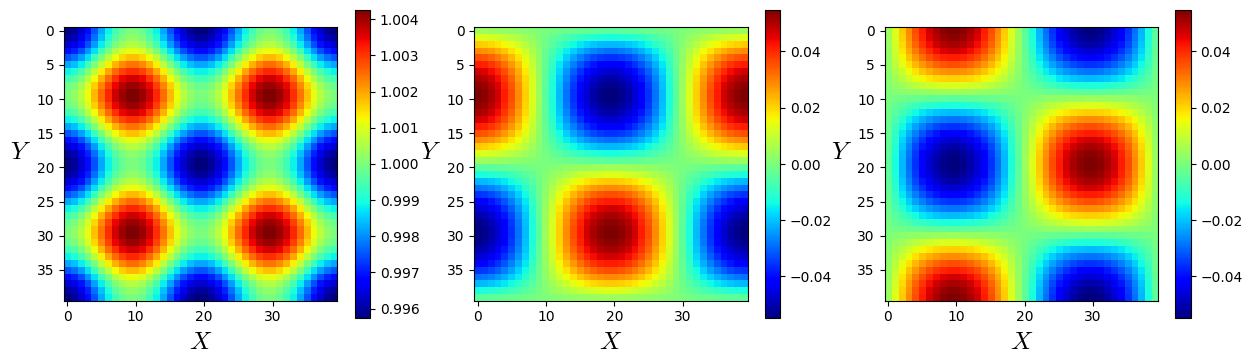

In [16]:
matplotlib.rcParams['mathtext.fontset'] = 'cm'
fig1, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(15,4))
img1=ax1.imshow(np.rot90(rho[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img1, ax=ax1)
ax1.set_xlabel('$X$',fontsize=18)
ax1.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0)
img2=ax2.imshow(np.rot90(Vx[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img2, ax=ax2)
ax2.set_xlabel('$X$',fontsize=18)
ax2.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 
img3=ax3.imshow(np.rot90(Vy[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img3, ax=ax3)
ax3.set_xlabel('$X$',fontsize=18)
ax3.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 

Text(0.5, 0, '$t$')

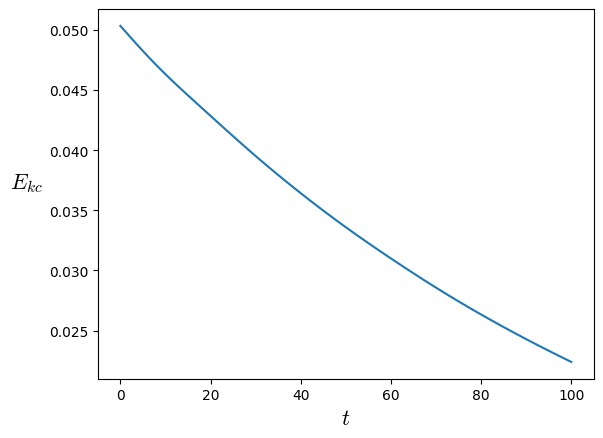

In [17]:
plt.plot(np.linspace(0,len(Enr),len(Enr)),Enr)
plt.ylabel('$E_{kc}$',fontsize=16,rotation=0,horizontalalignment='right')
plt.xlabel('$t$',fontsize=16)

Text(0.5, 0, '$t$')

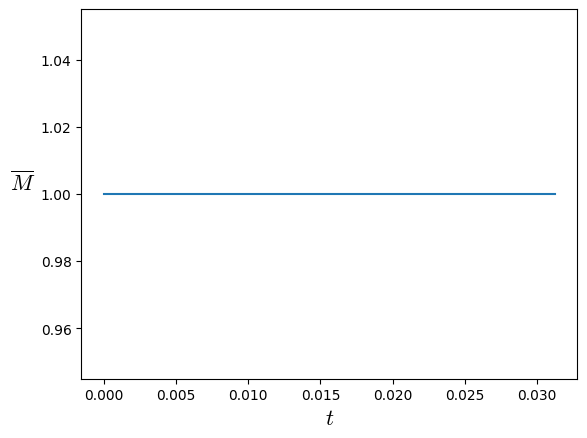

In [14]:
plt.plot(np.linspace(0,len(Mass),len(Mass))/Nx/r,Mass)
plt.ylabel('$\overline{M}$',fontsize=16,rotation=0,horizontalalignment='right')
plt.xlabel('$t$',fontsize=16)

## Temperature-Scaled Central Moments Collision

In [23]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pylab as plt
from IPython.display import display, Math
import time
# =========================Domain===========================================================
Nx = 40
Ny = Nx
# =================D2Q9 lattice=============================================================
w0 = 4.0 / 9.0; w1 = 1.0 / 9.0; w2 = 1.0 / 36.0
w = np.array([w0, w1, w1, w1, w1, w2, w2, w2, w2],dtype="float64")
cx = np.array([0, 1, 0, -1, 0, 1, -1, -1, 1], dtype="float64")
cy = np.array([0, 0, 1, 0, -1, 1, 1, -1, -1],dtype="float64")
cs = 1.0 / np.sqrt(3.0)
cs2 = cs**2
cs4 = cs**4
# ==========================================================================================
# Raw-moment basis
# m = [m00,m10,m01,m20,m02,m11,m21,m12,m22]
# m_pq = sum_i f_i cx_i^p cy_i^q
# ==========================================================================================
powers = [(0, 0),(1, 0),(0, 1),(2, 0),(0, 2),(1, 1),(2, 1),(1, 2),(2, 2)]
M = np.zeros((9, 9), dtype="float64")
for j, (px, py) in enumerate(powers):
    M[j, :] = cx**px * cy**py
Minv = np.linalg.inv(M)
# ===================Dimensionless parameters===============================================
uo = 1.0
ho = 1.0
Re = 30.0
nuo = uo * ho / Re
# ==============================Scaling=====================================================
dx = ho / Nx
r = 2.0**3
dt = dx / r
nu = dt * nuo / dx**2
ue = dt * uo / dx
tau = nu / cs2 + 0.5
rhoi = 1.0
mstep = 100
# ===========================Relaxation frequencies=========================================
omega2 = 1.0 / tau
omega3 = 1.0 / tau
omega4 = 1.0 / tau
display(Math(r"\tau=" + str(tau) + r"\qquad\nu=" + str(nu)))
display(Math(r"r=" + str(r) + r"\qquad \bar{u}=" + str(ue)))
display(Math(r"dx=" + str(dx)+ r"\qquad dt=" + str(dt)))
# ========================Fields============================================================
Mass = np.zeros(mstep, dtype="float64")
Enr  = np.zeros(mstep, dtype="float64")
rho = np.zeros((Nx, Ny), dtype="float64")
Vx = np.zeros((Nx, Ny), dtype="float64")
Vy = np.zeros((Nx, Ny), dtype="float64")
# ==========================================================================================
# Temperature field: theta = T/T0
# theta = 1 -> ordinary central moments
# Initially keep it uniform. Later we can introduce a nonuniform field.
# ==========================================================================================
theta = np.ones((Nx, Ny), dtype="float64")
# =====================Initial Taylor-Green vortex==========================================
xi = np.arange(Nx, dtype="float64") + 0.5
yi = np.arange(Ny, dtype="float64") + 0.5
Xi, Yi = np.meshgrid(xi,yi,indexing="ij")
rho = (rhoi- (rhoi * ue**2 / (4.0 * cs2)) * (np.cos(4.0 * np.pi * Xi / Nx)+ np.cos(4.0 * np.pi * Yi / Ny)))
Vx = (-ue * np.cos(2.0 * np.pi * Xi / Nx) * np.sin(2.0 * np.pi * Yi / Ny))
Vy = (ue * np.cos(2.0 * np.pi * Yi / Ny) * np.sin(2.0 * np.pi * Xi / Nx))
# =======================Distribution functions=============================================
f  = np.zeros((9, Nx, Ny), dtype="float64")
fp = np.zeros((9, Nx, Ny), dtype="float64")
# ==========================================================================================
# Initialization: Because theta = 1 initially, standard D2Q9 equilibrium is sufficient.
# ==========================================================================================
for k in range(9):
    cu = Vx * cx[k] + Vy * cy[k]
    f[k, :, :] = (w[k] * rho * (1.0 + cu / cs2 + 0.5 * cu**2 / cs4 - 0.5 * (Vx**2 + Vy**2) / cs2))
# =============================Main loop====================================================
start = time.time()
for kk in range(mstep):
    # =====================Macroscopic variables============================================
    rho = np.sum(f, axis=0)
    Vx = np.einsum("i,ixy->xy", cx, f) / rho
    Vy = np.einsum("i,ixy->xy", cy, f) / rho
    theta = np.einsum("i,ixy->xy", (cx-Vx)**2+(cy-Vy)**2, f) / (2.0*rho*cs2) # Fix This------------------
    # ======================================================================================
    # Relative peculiar velocity: c_i = xi_i - u
    # ======================================================================================
    Cx = cx[:, None, None] - Vx[None, :, :]
    Cy = cy[:, None, None] - Vy[None, :, :]
    # ======================================================================================
    # TEMPERATURE-SCALED RELATIVE VELOCITY: v_i = (xi_i - u) / sqrt(theta)
    # This corresponds to the basic variable used in Li, Shi & Shan.
    # ======================================================================================
    sqrt_theta = np.sqrt(theta)
    Vrelx = Cx / sqrt_theta[None, :, :]
    Vrely = Cy / sqrt_theta[None, :, :]
    # ======================================================================================
    # Temperature-scaled central moments: d_pq = sum_i f_i Vrelx^p Vrely^q
    # ======================================================================================
    d00 = np.sum(f, axis=0)
    d10 = np.sum(f * Vrelx, axis=0)
    d01 = np.sum(f * Vrely, axis=0)
    # ----------------------------Second order----------------------------------------------
    d20 = np.sum(f * Vrelx**2, axis=0)
    d02 = np.sum(f * Vrely**2, axis=0)
    d11 = np.sum(f * Vrelx * Vrely, axis=0)
    # ------------------------------Third order---------------------------------------------
    d21 = np.sum(f * Vrelx**2 * Vrely, axis=0)
    d12 = np.sum(f * Vrelx * Vrely**2, axis=0)
    # --------------------------Fourth order------------------------------------------------
    d22 = np.sum(f * Vrelx**2 * Vrely**2, axis=0)
    # ======================================================================================
    # Equilibrium temperature-scaled central moments
    # Because the thermal scale has already been removed:
    # <v_x^2> = cs^2 instead of <c_x^2> = theta cs^2.
    # ======================================================================================
    d00_eq = rho
    d10_eq = 0.0; d01_eq = 0.0
    d20_eq = rho * cs2
    d02_eq = rho * cs2
    d11_eq = 0.0; d21_eq = 0.0; d12_eq = 0.0
    d22_eq = rho * cs4
    # ======Collision in temperature-scaled central-moment space============================
    d00p = d00
    d10p = d10
    d01p = d01
    # ----------------------------Second-order RCM------------------------------------------
    d20p = (d20 - omega2 * (d20 - d20_eq) )
    d02p = (d02 - omega2 * (d02 - d02_eq) )
    d11p = (d11 - omega2 * (d11 - d11_eq) )
    # --------------------------Third-order RCM---------------------------------------------
    d21p = (d21 - omega3 * (d21 - d21_eq))
    d12p = (d12 - omega3 * (d12 - d12_eq) )
    # ---------------------------Fourth-order RCM-------------------------------------------
    # IMPORTANT:    # --------------------------------------------------------------------------------------
    # This direct fourth-order relaxation is pedagogical on D2Q9.
    # The Li-Shi-Shan paper filters the highest unsupported RCM.
    # We will implement that version next.
    # --------------------------------------------------------------------------------------
    d22p = (d22 - omega4 * (d22 - d22_eq) )
    # ======================================================================================
    # RCM -> ordinary CM: Since v = c / sqrt(theta) then kappa_pq = theta^((p+q)/2) d_pq
    # ======================================================================================
    k00p = d00p
    k10p = sqrt_theta * d10p
    k01p = sqrt_theta * d01p
    # -----------------------Second order---------------------------------------------------
    k20p = theta * d20p
    k02p = theta * d02p
    k11p = theta * d11p
    # ------------------------------Third order---------------------------------------------
    theta32 = theta**1.5
    k21p = theta32 * d21p
    k12p = theta32 * d12p
    # -----------------------------Fourth order---------------------------------------------
    k22p = theta**2 * d22p
    # ======================================================================================
    # CENTRAL MOMENTS -> RAW MOMENTS: Binomial transformation
    # ======================================================================================
    m00 = k00p
    # ------------------------First order---------------------------------------------------
    m10 = (k10p + Vx * k00p )
    m01 = (k01p + Vy * k00p )
    # -------------------------------Second order-------------------------------------------
    m20 = (k20p + 2.0 * Vx * k10p + Vx**2 * k00p )
    m02 = (k02p + 2.0 * Vy * k01p + Vy**2 * k00p )
    m11 = (k11p + Vx * k01p + Vy * k10p + Vx * Vy * k00p )
    # -------------------------Third order--------------------------------------------------
    m21 = (k21p + Vy * k20p + 2.0 * Vx * k11p + 2.0 * Vx * Vy * k10p + Vx**2 * k01p + Vx**2 * Vy * k00p)
    m12 = (k12p + Vx * k02p + 2.0 * Vy * k11p + 2.0 * Vx * Vy * k01p + Vy**2 * k10p + Vx * Vy**2 * k00p)
    # -----------------------Fourth order---------------------------------------------------
    m22 = (k22p + 2.0 * Vy * k21p + 2.0 * Vx * k12p + Vy**2 * k20p + Vx**2 * k02p + 4.0 * Vx * Vy * k11p 
           + 2.0 * Vx * Vy**2 * k10p + 2.0 * Vx**2 * Vy * k01p + Vx**2 * Vy**2 * k00p )
    # ====================Assemble raw moments==============================================
    mpost = np.stack([m00,m10,m01,m20,m02,m11,m21,m12,m22], axis=0 )
    # ====================Raw moments -> distribution functions=============================
    fp = np.einsum("ij,jxy->ixy",Minv,mpost)
    # =======================Streaming======================================================
    for k in range(9):
        f[k, :, :] = np.roll(np.roll(fp[k, :, :], int(cx[k]), axis=0 ), int(cy[k]),axis=1)
    # ===========Macroscopic variables after streaming======================================
    rho = np.sum(f, axis=0)
    Vx = np.einsum("i,ixy->xy",cx,f) / rho
    Vy = np.einsum("i,ixy->xy",cy,f) / rho
    # ===============================Diagnostics============================================
    Mass[kk] = np.mean(rho)
    Umed = np.mean(np.abs(Vx))
    Enr[kk] = Umed
    print(kk,"|Umed| =",Umed," Mass =",Mass[kk]," theta(mean) =",np.mean(theta))
print("Elapsed time =", time.time() - start)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

ValueError: operands could not be broadcast together with shapes (9,) (40,40) 

In [22]:
d20 = np.sum(f * Vrelx**2, axis=0)
print("max scaled/unscaled difference =", np.max( np.abs(d20 - np.sum(f * Cx**2, axis=0))))

max scaled/unscaled difference = 0.0
